# LIBRARY

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [3]:
import pandas as pd

def analyze_feature(df, colonna, quantili=[0.1,0.25,0.50, 0.75,0.9,0.99]):
    serie = df[colonna] 
    
    # CAL values equal to 0
    num_zero = (serie == 0).sum()
    presenza_zero = num_zero > 0
    
    # CAL negative values
    num_negativi = (serie < 0).sum()
    presenza_negativi = num_negativi > 0
    
    # CAL range (min and max)
    valore_min = serie.min()
    valore_max = serie.max()
    range_valori = valore_max - valore_min

     # CAL quantiles
    valori_quantili = serie.quantile(quantili)
    
    # Stampa risultati
    print(f"Analyzed column: {colonna}")
    print(f"Presence of values equal to 0: {presenza_zero}")
    print(f"Number of values equal to 0: {num_zero}")
    print(f"Presence of negative values: {presenza_negativi}")
    print(f"Number of negative values: {num_negativi}")    
    print(f"Minimum value: {valore_min}")
    print(f"Maximum value: {valore_max}")
    print(f"Range (max - min): {range_valori}")

    print(f"\nQuantiles:")
    for q, v in valori_quantili.items():
        print(f"  Q{int(q*100)} ({q}): {v}")

# IMPORT DF

In [4]:
file_path = "../1.DATASET/CMI_NN_V2.csv"
df=pd.read_csv(file_path)
df.head(3)

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,0,5,0,51.0,16.877316,46.0,50.8,932.498,NaN,5.0,...,1.0,19.5413,32.6909,NaN,3.0,2.0,82.152821,4.611111,17.883041,6.5
1,1,9,0,NaN,14.035590,48.0,46.0,936.656,70.0,NaN,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.0
2,2,10,1,71.0,16.648696,56.5,75.6,1115.380,94.0,5.0,...,2.0,23.8933,42.0000,54.0,2.0,0.0,82.333333,27.000000,12.450000,10.0


In [5]:
df.columns

Index(['id', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFM', 'BIA-BIA_FMI',
       'BIA-BIA_Fat', 'BIA-BIA_LST', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

## CORRELATION MATRIX

In [6]:
cols=[ 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFM', 'BIA-BIA_FMI',
       'BIA-BIA_Fat', 'BIA-BIA_LST', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL']

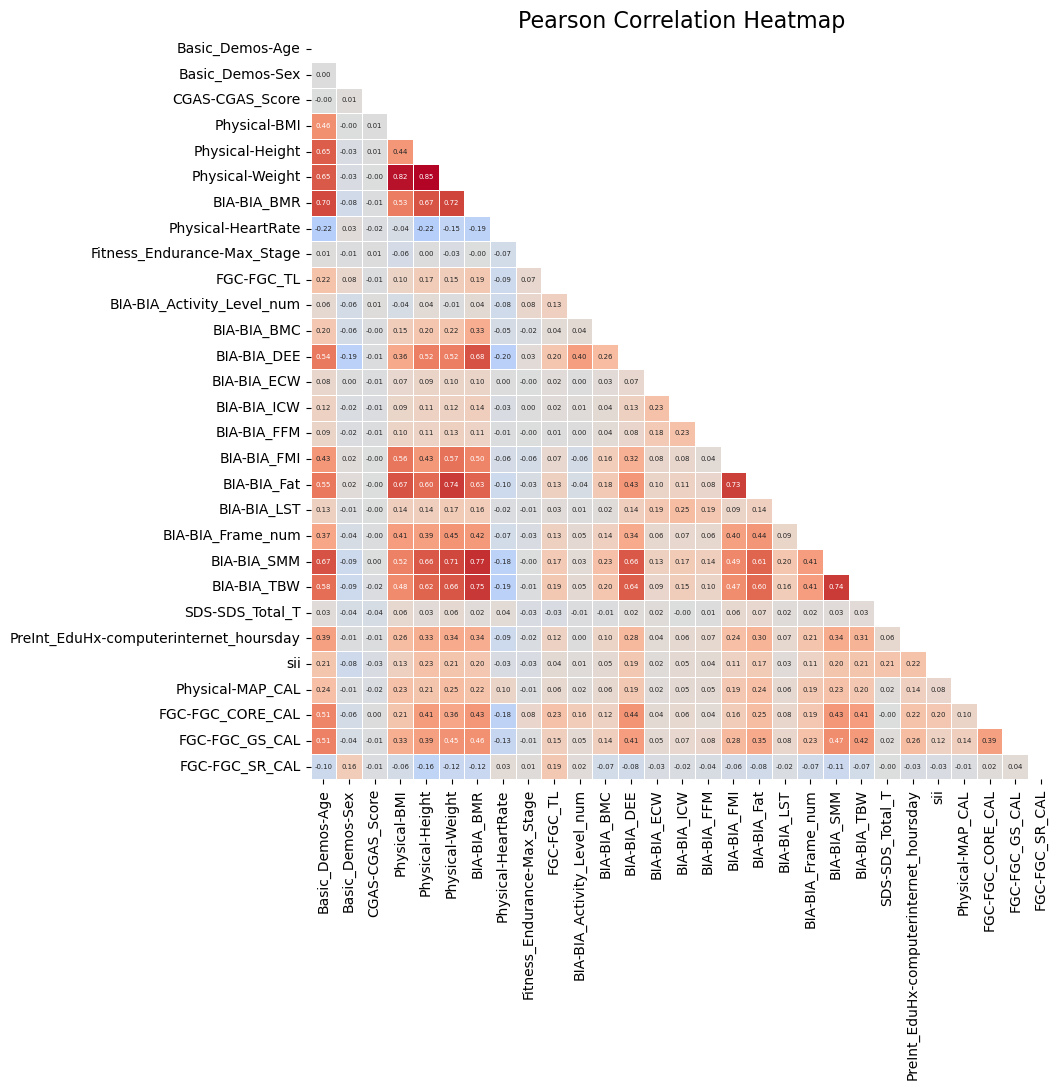

In [7]:
# column selection
df_corr = df[cols]
 
# Pearson correlation
corr = df_corr.corr(method='pearson')
 
mask = np.triu(np.ones_like(corr, dtype=bool))
 
# heatmap
plt.figure(figsize=(11, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,             
    fmt=".2f",              
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar=False,
    annot_kws={"size": 5},   
    cbar_kws={"shrink": 0.8}
)
 
plt.title("Pearson Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

## FINAL ATRIBUTES 

In [8]:
df_clean=df[['id', 'Basic_Demos-Age', 
       'Basic_Demos-Sex',
       'Physical-BMI', 
       'Physical-Height', 
       'Physical-Weight',
       'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 
       'FGC-FGC_GS_CAL', 
       'FGC-FGC_SR_CAL',
       'BIA-BIA_BMR',
       'BIA-BIA_Activity_Level_num', 
       'BIA-BIA_BMC',
       'BIA-BIA_DEE',
       'BIA-BIA_FFM', 
       'BIA-BIA_Fat', 
       'BIA-BIA_Frame_num', 
       'BIA-BIA_SMM',
       'BIA-BIA_TBW', 
        'sii'
       ]].copy()

In [9]:
df_clean.dropna().info()

<class 'pandas.core.frame.DataFrame'>
Index: 8459 entries, 0 to 8459
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          8459 non-null   int64  
 1   Basic_Demos-Age             8459 non-null   int64  
 2   Basic_Demos-Sex             8459 non-null   int64  
 3   Physical-BMI                8459 non-null   float64
 4   Physical-Height             8459 non-null   float64
 5   Physical-Weight             8459 non-null   float64
 6   Physical-MAP_CAL            8459 non-null   float64
 7   FGC-FGC_CORE_CAL            8459 non-null   float64
 8   FGC-FGC_GS_CAL              8459 non-null   float64
 9   FGC-FGC_SR_CAL              8459 non-null   float64
 10  BIA-BIA_BMR                 8459 non-null   float64
 11  BIA-BIA_Activity_Level_num  8459 non-null   float64
 12  BIA-BIA_BMC                 8459 non-null   float64
 13  BIA-BIA_DEE                 8459 non-n

# TEST

## DESCRIBE 

In [10]:
df_clean.describe()

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_BMR,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
count,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8459.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000
mean,4229.500000,10.240189,0.402364,19.398079,56.478933,92.232099,84.638161,15.563148,20.245747,8.404002,1167.760984,2.769031,4.910396,1897.984598,75.537319,21.236714,1.717376,30.777211,44.874955,0.443853
std,2442.335972,3.574680,0.490404,4.508203,7.749960,41.741472,9.718417,11.568799,5.638581,2.031050,214.669213,0.822652,2.528473,457.433317,240.863071,16.872220,0.567185,12.588745,14.288875,0.731014
min,0.000000,5.000000,0.000000,8.522436,33.000000,31.800000,37.666667,0.500000,0.100000,0.500000,813.397000,1.000000,0.009889,1073.450000,28.900000,0.026117,1.000000,4.655730,20.589200,0.000000
25%,2114.750000,7.000000,0.000000,16.492196,50.860000,62.600000,79.791667,8.000000,18.025000,7.500000,1030.073692,2.000000,3.340191,1602.294854,50.951966,10.437449,1.000000,23.381628,36.939644,0.000000
50%,4229.500000,10.000000,0.000000,17.937682,55.125000,78.111593,83.333333,12.787145,18.613018,8.500000,1115.380000,3.000000,4.505371,1804.463865,61.066200,15.811750,2.000000,26.072588,42.000000,0.000000
75%,6344.250000,12.000000,1.000000,21.232154,62.300000,113.309273,88.166667,20.500000,20.626092,9.000000,1288.492418,3.000000,5.796779,2084.150000,76.500000,27.437131,2.000000,36.083425,47.137886,1.000000
max,8459.000000,22.000000,1.000000,59.132048,78.500000,315.923401,164.333333,150.000000,115.100000,21.000000,2993.189524,5.000000,47.788059,7994.080000,8799.080000,153.820000,3.000000,215.413000,143.762000,3.000000


## RULES

### BIA-BIA_Fat

In [11]:
df_clean[(df_clean["Physical-Weight"] < df_clean["BIA-BIA_Fat"])]

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_BMR,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
3473,3473,6,1,15.102918,41.5,37.0,88.0,12.0,18.613018,10.5,1004.87,3.0,1.73684,1607.8,49.2953,59.999567,1.0,25.567,34.1988,0.0


In [12]:
corrupted_bia_mask = (
    (df["BIA-BIA_Fat"] > df["Physical-Weight"]) 
)
print(f"Corrupted BIA rows: {corrupted_bia_mask.sum()}")

Corrupted BIA rows: 1


In [13]:
MAX_FAT_PCT = 0.31
df_clean.loc[corrupted_bia_mask, "BIA-BIA_Fat"] = (
    df_clean.loc[corrupted_bia_mask, "Physical-Weight"] * MAX_FAT_PCT
)

In [14]:
df_clean[(df_clean["Physical-Weight"] < df_clean["BIA-BIA_Fat"])]

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_BMR,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii


In [15]:
df_clean.iloc[[3473]]

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_BMR,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
3473,3473,6,1,15.102918,41.5,37.0,88.0,12.0,18.613018,10.5,1004.87,3.0,1.73684,1607.8,49.2953,11.47,1.0,25.567,34.1988,0.0


### BIA-BIA_FFM

In [16]:
df_clean[["Physical-Weight", "BIA-BIA_FFM","BIA-BIA_Fat"]][(df_clean["Physical-Weight"] < df_clean["BIA-BIA_FFM"]) | (df_clean["BIA-BIA_FFM"].isna())]

,Physical-Weight,BIA-BIA_FFM,BIA-BIA_Fat
4,77.368163,93.400000,15.811750
8,82.617354,92.100000,17.948622
30,79.640398,92.100000,28.617678
34,48.000000,50.400000,9.627504
37,59.800000,61.066200,12.823800
...,...,...,...
8318,38.795270,41.399206,2.594262
8358,41.788709,44.799956,4.330144
8370,79.319548,81.354079,16.464579
8405,77.929003,91.150346,17.958033


In [17]:
corrupted_bia_mask = (
    (df_clean["BIA-BIA_FFM"] > df_clean["Physical-Weight"])  | (df_clean["BIA-BIA_FFM"].isna())
)
print(f"Corrupted BIA rows: {corrupted_bia_mask.sum()}")

Corrupted BIA rows: 841


In [18]:
df_clean["BIA-BIA_FFM"] = df_clean["Physical-Weight"] - df_clean["BIA-BIA_Fat"]

In [19]:
df_clean[["Physical-Weight", "BIA-BIA_FFM"]][df_clean["Physical-Weight"] < df_clean["BIA-BIA_FFM"]]

,Physical-Weight,BIA-BIA_FFM


In [20]:
df_clean[["Physical-Weight", "BIA-BIA_FFM","BIA-BIA_Fat"]].iloc[[4]]

,Physical-Weight,BIA-BIA_FFM,BIA-BIA_Fat
4,77.368163,61.556413,15.81175


### BIA-BIA_TBW

In [21]:
df_clean[["Physical-Weight", "BIA-BIA_TBW"]][df_clean["Physical-Weight"] < df_clean["BIA-BIA_TBW"]]

,Physical-Weight,BIA-BIA_TBW
71,38.400000,42.000
166,39.897013,42.625
217,38.642390,42.000
256,38.642390,42.000
263,40.398862,42.625
...,...,...
4274,42.155334,42.625
7129,35.408175,42.625
7371,41.477196,42.625
7699,40.936221,42.625


In [22]:
corrupted_bia_mask = (
    df_clean["Physical-Weight"] < df_clean["BIA-BIA_TBW"] 
)
print({corrupted_bia_mask.sum()})

{89}


In [23]:
MAX_TBW_PCT = 0.80

df_clean.loc[corrupted_bia_mask, "BIA-BIA_TBW"] = (
    df_clean.loc[corrupted_bia_mask, "Physical-Weight"] * MAX_TBW_PCT
)

In [24]:
df_clean[["Physical-Weight", "BIA-BIA_TBW"]][df_clean["Physical-Weight"] < df_clean["BIA-BIA_TBW"]]


,Physical-Weight,BIA-BIA_TBW


In [25]:
df_clean[["Physical-Weight", "BIA-BIA_TBW"]].iloc[[71]]

,Physical-Weight,BIA-BIA_TBW
71,38.4,30.72


### BIA-BIA_SMM

In [26]:
df_clean[["Basic_Demos-Age","Basic_Demos-Sex","BIA-BIA_SMM", "Physical-Height","Physical-Weight"]][df_clean["Physical-Weight"] < df_clean["BIA-BIA_SMM"]]

,Basic_Demos-Age,Basic_Demos-Sex,BIA-BIA_SMM,Physical-Height,Physical-Weight
1045,21,1,53.03920,42.00,45.010059
1287,5,0,83.83745,45.00,49.600000
1464,13,0,67.98365,42.00,45.010059
2738,7,0,83.83745,48.03,49.200000
2770,9,0,83.83745,56.00,75.600000
3147,8,0,83.83745,48.00,52.800000
3162,15,0,67.98365,42.00,48.177525
3205,9,1,83.83745,54.00,70.400000
3729,11,1,83.83745,55.00,77.185617
3842,15,0,67.98365,42.00,45.010059


In [27]:
round(df_clean[["Physical-Height"]],0).value_counts()

Physical-Height
55.0               971
56.0               500
54.0               435
50.0               414
48.0               356
52.0               353
58.0               348
49.0               321
57.0               321
42.0               317
51.0               302
64.0               271
66.0               268
60.0               267
53.0               265
65.0               243
62.0               220
63.0               209
67.0               201
59.0               200
68.0               194
47.0               193
46.0               192
61.0               174
70.0               160
69.0               156
71.0               113
72.0               101
44.0                90
45.0                80
73.0                70
43.0                56
74.0                39
75.0                21
76.0                16
40.0                 6
41.0                 6
78.0                 5
77.0                 2
36.0                 1
39.0                 1
38.0                 1
33.0              

In [28]:
corrupted_bia_mask = (
    df_clean["BIA-BIA_SMM"] > df_clean["BIA-BIA_FFM"]
)
print({corrupted_bia_mask.sum()})

{173}


In [29]:
MAX_SMM_PCT = 0.50

df_clean.loc[corrupted_bia_mask, "BIA-BIA_SMM"] = (
    df_clean.loc[corrupted_bia_mask, "BIA-BIA_FFM"] * MAX_SMM_PCT
)

In [30]:
df_clean[["Basic_Demos-Age","Basic_Demos-Sex","BIA-BIA_SMM", "Physical-Height","Physical-Weight"]][df_clean["Physical-Weight"] < df_clean["BIA-BIA_SMM"]]

,Basic_Demos-Age,Basic_Demos-Sex,BIA-BIA_SMM,Physical-Height,Physical-Weight


# FINAL

In [31]:
df_clean.describe()

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_BMR,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
count,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000
mean,4229.500000,10.240189,0.402364,19.398079,56.478933,92.232099,84.638161,15.563148,20.245747,8.404002,1167.760984,2.769031,4.910396,1897.984598,71.001122,21.230978,1.717376,30.192003,44.758863,0.443853
std,2442.335972,3.574680,0.490404,4.508203,7.749960,41.741472,9.718417,11.568799,5.638581,2.031050,214.669213,0.822652,2.528473,457.433317,31.257327,16.867289,0.567185,12.277224,14.350354,0.731014
min,0.000000,5.000000,0.000000,8.522436,33.000000,31.800000,37.666667,0.500000,0.100000,0.500000,813.397000,1.000000,0.009889,1073.450000,2.040144,0.026117,1.000000,1.020072,20.589200,0.000000
25%,2114.750000,7.000000,0.000000,16.492196,50.860000,62.600000,79.791667,8.000000,18.025000,7.500000,1030.073692,2.000000,3.340191,1602.294854,50.420695,10.437449,1.000000,22.870479,36.559647,0.000000
50%,4229.500000,10.000000,0.000000,17.937682,55.125000,78.111593,83.333333,12.787145,18.613018,8.500000,1115.380000,3.000000,4.505371,1804.463865,62.139201,15.811750,2.000000,25.725700,42.000000,0.000000
75%,6344.250000,12.000000,1.000000,21.232154,62.300000,113.309273,88.166667,20.500000,20.626092,9.000000,1288.492418,3.000000,5.796779,2084.150000,84.177760,27.425193,2.000000,35.568700,47.129902,1.000000
max,8459.000000,22.000000,1.000000,59.132048,78.500000,315.923401,164.333333,150.000000,115.100000,21.000000,2993.189524,5.000000,47.788059,7994.080000,268.694823,153.820000,3.000000,119.085000,143.762000,3.000000


In [32]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8460 entries, 0 to 8459
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          8460 non-null   int64  
 1   Basic_Demos-Age             8460 non-null   int64  
 2   Basic_Demos-Sex             8460 non-null   int64  
 3   Physical-BMI                8460 non-null   float64
 4   Physical-Height             8460 non-null   float64
 5   Physical-Weight             8460 non-null   float64
 6   Physical-MAP_CAL            8460 non-null   float64
 7   FGC-FGC_CORE_CAL            8460 non-null   float64
 8   FGC-FGC_GS_CAL              8460 non-null   float64
 9   FGC-FGC_SR_CAL              8460 non-null   float64
 10  BIA-BIA_BMR                 8460 non-null   float64
 11  BIA-BIA_Activity_Level_num  8460 non-null   float64
 12  BIA-BIA_BMC                 8460 non-null   float64
 13  BIA-BIA_DEE                 8460 

In [33]:
analyze_feature(df_clean, 'BIA-BIA_FFM')

Analyzed column: BIA-BIA_FFM
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 2.0401442114793653
Maximum value: 268.6948232434999
Range (max - min): 266.65467903202057

Quantiles:
  Q10 (0.1): 41.40108725161991
  Q25 (0.25): 50.42069513705726
  Q50 (0.5): 62.13920136411273
  Q75 (0.75): 84.17775993356837
  Q90 (0.9): 113.64369893934682
  Q99 (0.99): 184.11208873525064


In [34]:
df_clean.to_csv('../1.DATASET/CMI_FINAL.csv', index=False)